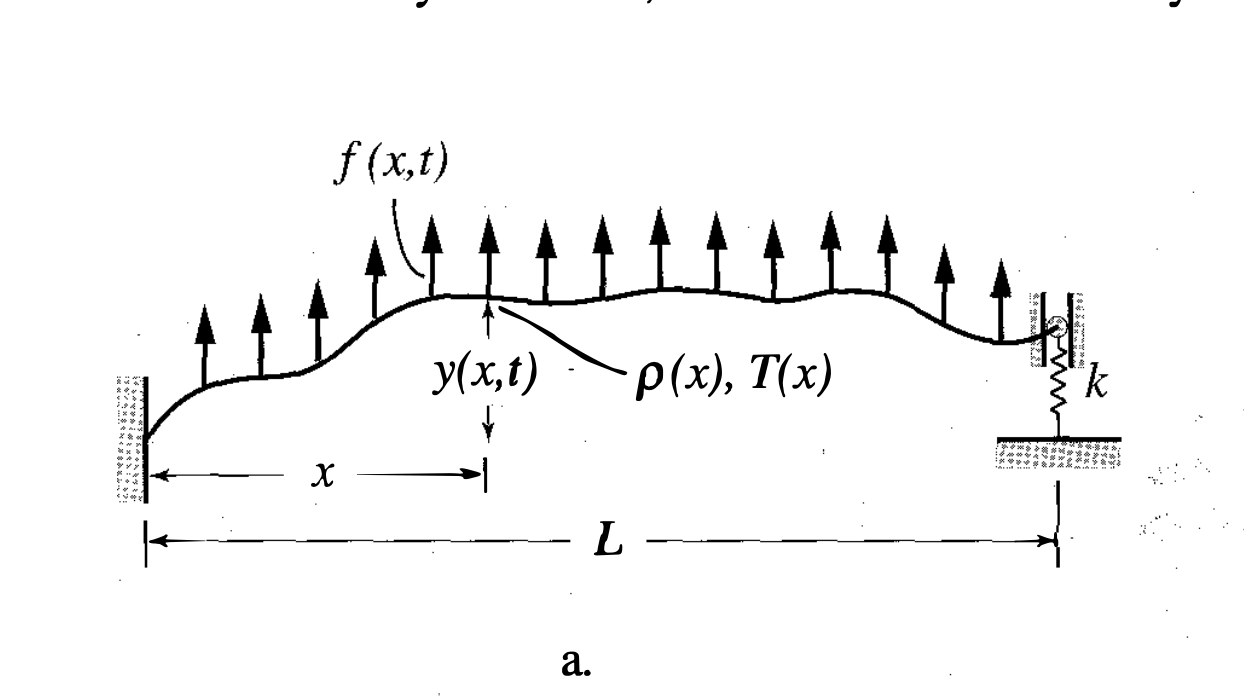
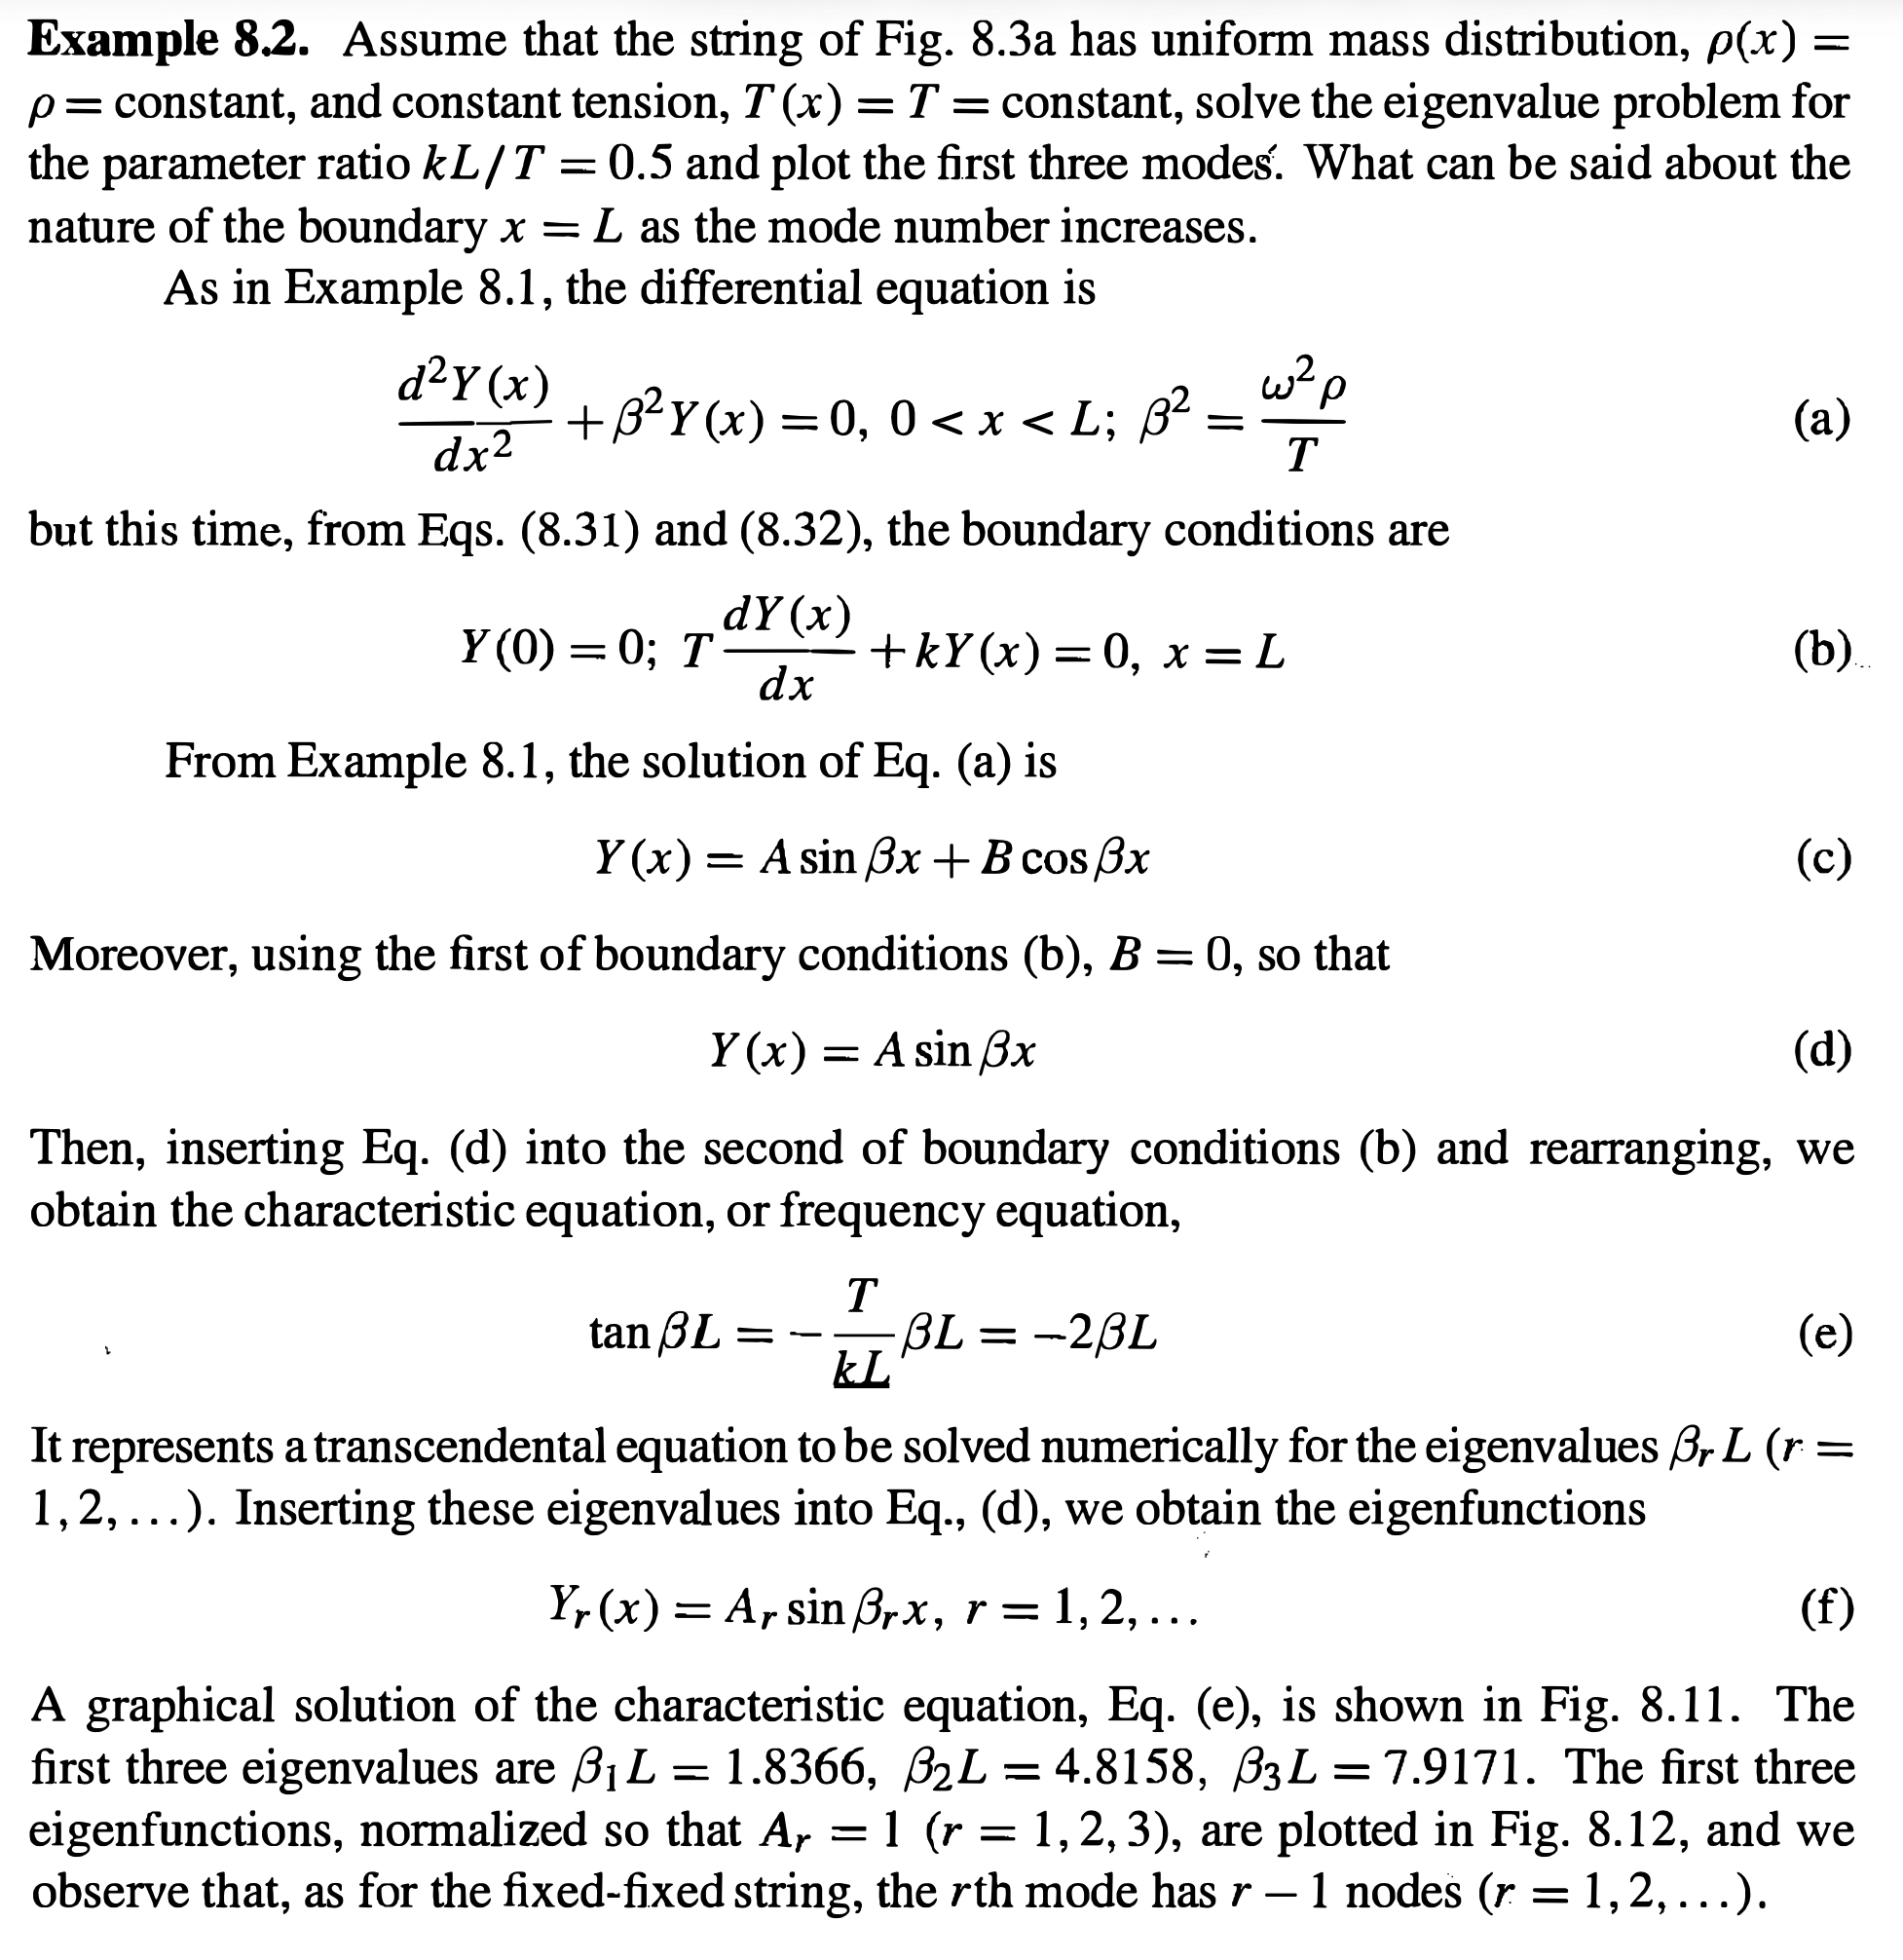

Calculated Eigenvalues (beta*L):
  beta_1*L = 1.8366
  beta_2*L = 4.8158
  beta_3*L = 7.9171


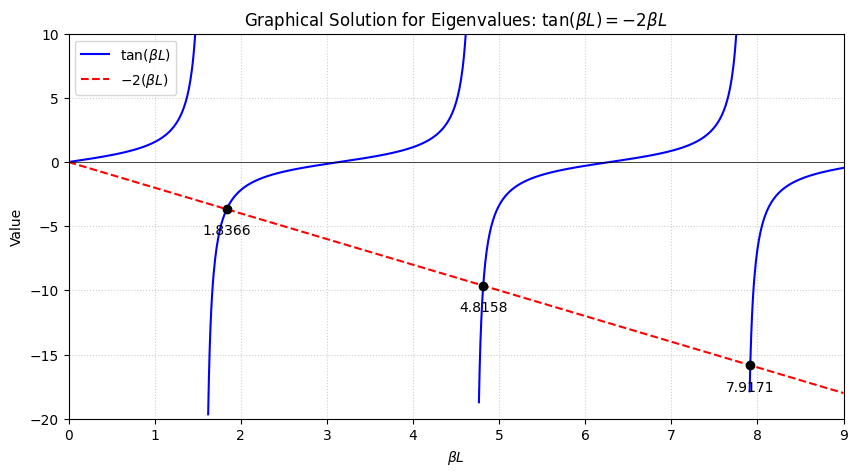

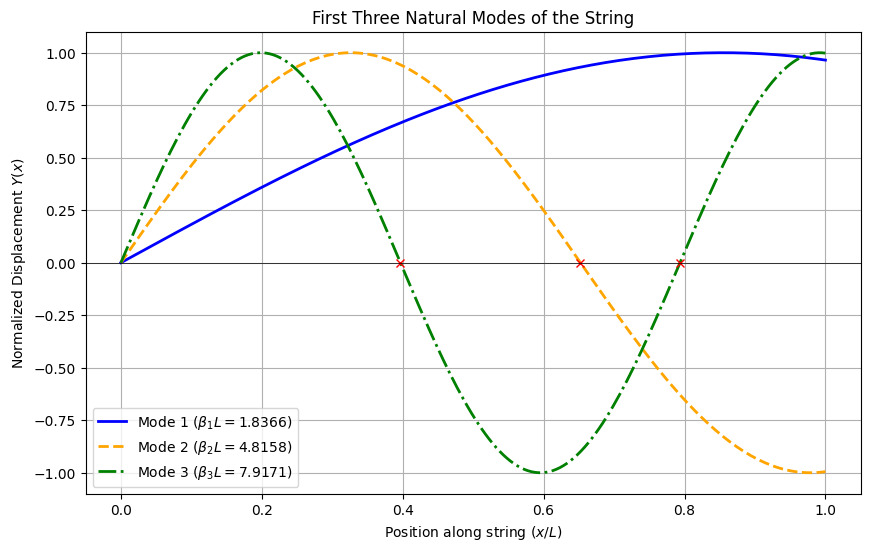

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# ==========================================
# 1. 参数定义
# ==========================================
# 根据 Example 8.2, kL/T = 0.5, 所以 slope = - T/(kL) = -1/0.5 = -2
slope = -2.0 

def characteristic_eq(x):
    """
    特征方程: tan(x) = -2x
    即: tan(x) + 2x = 0
    """
    return np.tan(x) - slope * x

# ==========================================
# 2. 求解特征值 (Eigenvalues)
# ==========================================
# 我们知道根位于 (n+0.5)pi 附近。
# 第1个根在 (pi/2, pi) 之间
# 第2个根在 (3pi/2, 2pi) 之间
# 第3个根在 (5pi/2, 3pi) 之间
initial_guesses = [2.0, 4.9, 7.9] # 初始猜测值
eigenvalues = []

print("Calculated Eigenvalues (beta*L):")
for guess in initial_guesses:
    # 使用 fsolve 寻找数值解
    root = fsolve(characteristic_eq, guess)[0]
    eigenvalues.append(root)
    print(f"  beta_{len(eigenvalues)}*L = {root:.4f}")

# 验证是否与图片中的值一致 (1.8366, 4.8158, 7.9171)

# ==========================================
# 3. 绘图 1: 图解特征方程 (Intersection)
# ==========================================
x_vals = np.linspace(0, 9, 1000)
y_tan = np.tan(x_vals)
y_line = slope * x_vals

# 处理 tan 的渐近线，防止绘图连线
y_tan[np.abs(y_tan) > 20] = np.nan

plt.figure(figsize=(10, 5))
plt.plot(x_vals, y_tan, label=r'$\tan(\beta L)$', color='blue', linewidth=1.5)
plt.plot(x_vals, y_line, label=r'$-2(\beta L)$', color='red', linestyle='--', linewidth=1.5)

# 标记交点
for val in eigenvalues:
    plt.plot(val, np.tan(val), 'ko') # 黑点标记
    plt.text(val, np.tan(val)-2, f'{val:.4f}', ha='center', fontsize=10)

plt.ylim(-20, 10)
plt.xlim(0, 9)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel(r'$\beta L$')
plt.ylabel('Value')
plt.title('Graphical Solution for Eigenvalues: $\\tan(\\beta L) = -2\\beta L$')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# ==========================================
# 4. 绘图 2: 固有振型 (Natural Modes)
# ==========================================
x_norm = np.linspace(0, 1, 200) # x/L from 0 to 1

plt.figure(figsize=(10, 6))

colors = ['blue', 'orange', 'green']
line_styles = ['-', '--', '-.']

for i, beta_L in enumerate(eigenvalues):
    # Mode shape formula: Y(x) = sin(beta_L * x/L)
    # Normlized so amplitude is 1 (A_r = 1 as per text)
    mode_shape = np.sin(beta_L * x_norm)
    
    label_str = f'Mode {i+1} ($\\beta_{i+1}L = {beta_L:.4f}$)'
    plt.plot(x_norm, mode_shape, label=label_str, color=colors[i], linestyle=line_styles[i], linewidth=2)

    # 标记节点 (Nodes)
    # 节点是 sin(beta_L * xi) = 0 的地方
    # 除了 x=0，节点位置在 xi = n*pi / beta_L
    n_nodes = int(beta_L / np.pi)
    for n in range(1, n_nodes + 1):
        node_x = n * np.pi / beta_L
        if node_x < 1.0: # 确保在梁的范围内
            plt.plot(node_x, 0, 'rx', markersize=6) # 红色叉号标记节点

plt.xlabel(r'Position along string ($x/L$)')
plt.ylabel(r'Normalized Displacement $Y(x)$')
plt.title('First Three Natural Modes of the String')
plt.axhline(0, color='black', linewidth=0.5)
plt.legend()
plt.grid(True)
plt.show()

$$\tan(\beta L) = - \frac{T}{kL} (\beta L)$$

----

可改数值版如下

当前参数设置:
L = 1.0, T = 1.0, k = 0.5
特征方程参数 (T/kL) = 2.0
求解方程: tan(x) = - 2.0 * x
------------------------------
计算出的特征值 (beta * L):
Mode 1: beta1L = 1.83660
Mode 2: beta2L = 4.81584
Mode 3: beta3L = 7.91705


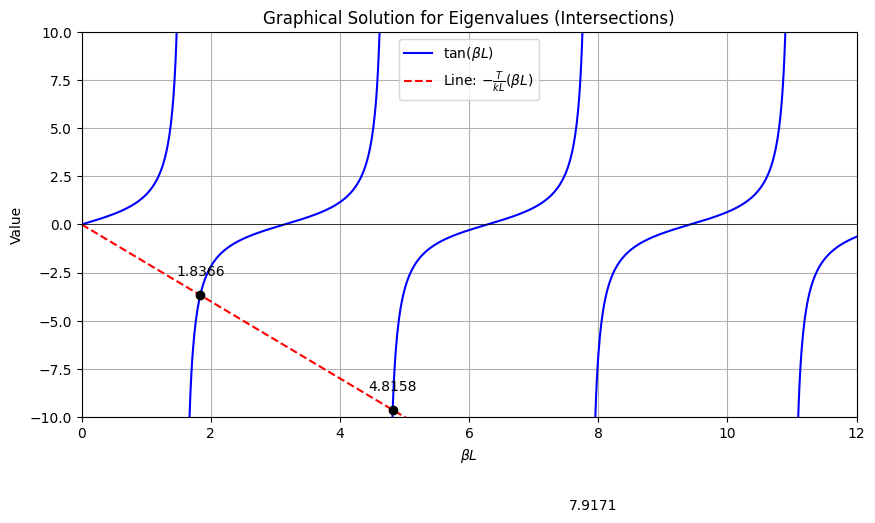

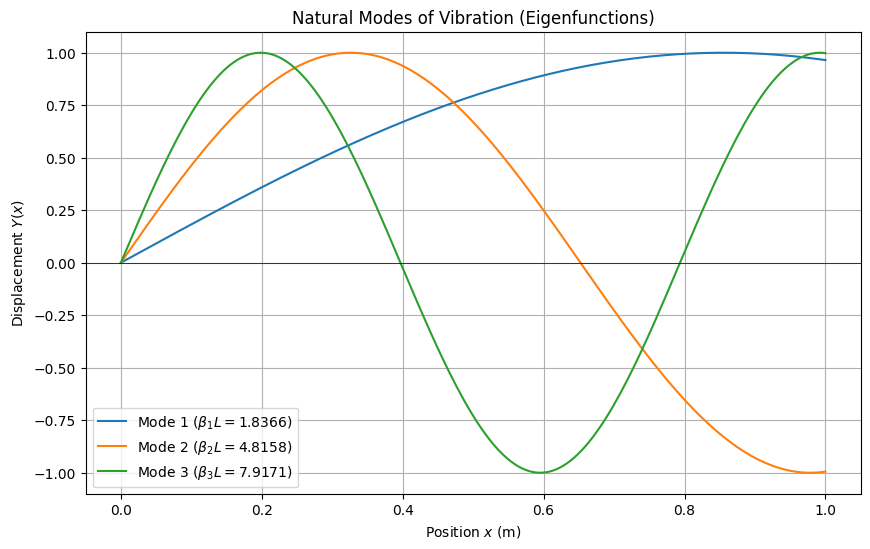

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# ==========================================
# 1. 参数设置区 (考试时修改这里)
# ==========================================
# 题目给定的参数比值 kL/T = 0.5
# 为了方便，我们可以设 L=1, T=1, 这样 k 就要设为 0.5
L_val = 1.0       # 弦长 L
T_val = 1.0       # 张力 T
k_val = 0.5       # 弹簧刚度 k

# 计算关键无量纲参数: alpha = T / (k * L)
# 对应的方程是: tan(x) = - alpha * x
# 图片公式 (e): tan(beta*L) = - (T/kL) * (beta*L)
alpha = T_val / (k_val * L_val)

print(f"当前参数设置:")
print(f"L = {L_val}, T = {T_val}, k = {k_val}")
print(f"特征方程参数 (T/kL) = {alpha}")
print(f"求解方程: tan(x) = - {alpha} * x")
print("-" * 30)

# ==========================================
# 2. 图解法：画交点找 Eigenvalues
# ==========================================
# 设置 x (即 beta*L) 的范围，画前 3-4 个根
x_max = 12  
x = np.linspace(0, x_max, 1000)

# 定义两个函数
y1 = np.tan(x)
y2 = -alpha * x

# 处理 tan(x) 的间断点 (把无穷大的地方设为 NaN 以便绘图美观)
y1[:-1][np.diff(y1) < 0] = np.nan 

plt.figure(figsize=(10, 5))
plt.plot(x, y1, label=r'$\tan(\beta L)$', color='blue', linewidth=1.5)
plt.plot(x, y2, label=r'Line: $-\frac{T}{kL}(\beta L)$', color='red', linestyle='--', linewidth=1.5)

# 限制 y轴范围方便观察
plt.ylim(-10, 10)
plt.xlim(0, x_max)
plt.xlabel(r'$\beta L$')
plt.ylabel('Value')
plt.title('Graphical Solution for Eigenvalues (Intersections)')
plt.grid(True)
plt.legend()
plt.axhline(0, color='black', linewidth=0.5)

# ==========================================
# 3. 数值求解：计算精确的 beta*L
# ==========================================
def characteristic_eq(x):
    return np.tan(x) + alpha * x

eigenvalues_betaL = []
print("计算出的特征值 (beta * L):")

# 在每个区间 (n*pi + pi/2, (n+1)*pi) 寻找根
# 因为直线斜率是负的，根在第二、四象限。对于 x>0，根在 (pi/2, pi), (3pi/2, 2pi) 等区间
for n in range(3): # 找前3个根
    # 估算搜索区间
    lower_bound = n * np.pi + np.pi/2 + 0.01 # 稍微避开渐近线
    upper_bound = (n + 1) * np.pi - 0.01
    
    # 使用 Brent 方法求根
    try:
        root = brentq(characteristic_eq, lower_bound, upper_bound)
        eigenvalues_betaL.append(root)
        print(f"Mode {n+1}: beta{n+1}L = {root:.5f}")
        # 在图上标出交点
        plt.plot(root, -alpha*root, 'ko') 
        plt.text(root, -alpha*root + 1, f'{root:.4f}', ha='center')
    except:
        print(f"Mode {n+1}: 在区间 {lower_bound:.2f}-{upper_bound:.2f} 未找到根")

plt.show()

# ==========================================
# 4. 绘制 Natural Modes (振型图)
# ==========================================
plt.figure(figsize=(10, 6))

x_plot = np.linspace(0, L_val, 200) # 实际物理坐标 x

for i, betaL in enumerate(eigenvalues_betaL):
    # 计算 beta
    beta = betaL / L_val
    
    # 振型函数 Y(x) = sin(beta * x) (归一化幅度为1)
    Y = np.sin(beta * x_plot)
    
    # 绘图
    plt.plot(x_plot, Y, label=f'Mode {i+1} ($\\beta_{i+1} L = {betaL:.4f}$)')

plt.xlabel('Position $x$ (m)')
plt.ylabel('Displacement $Y(x)$')
plt.title('Natural Modes of Vibration (Eigenfunctions)')
plt.axhline(0, color='black', linewidth=0.5)
plt.grid(True)
plt.legend()
plt.show()


Mode  | beta*L     | omega (rad/s)   | freq (Hz) 
--------------------------------------------------
1     | 1.8366     | 183.6597        | 29.2304   
2     | 4.8158     | 481.5842        | 76.6465   
3     | 7.9171     | 791.7053        | 126.0038  


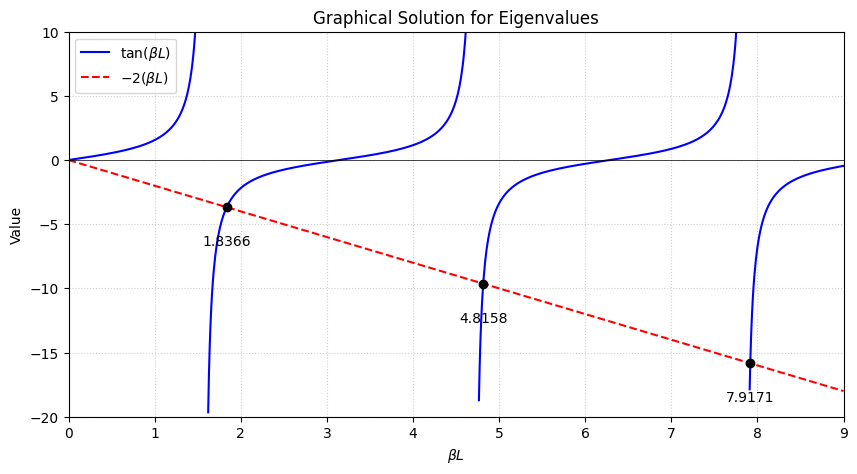

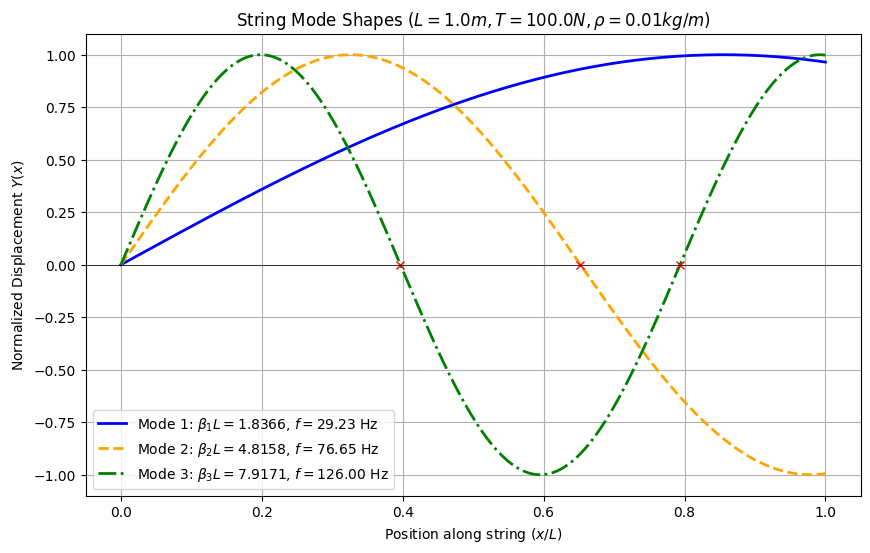

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# ==========================================
# 1. 参数定义 (物理参数 & 几何参数)
# ==========================================
# ------------------------------------------
# [新增] 物理参数，用于计算频率
# ------------------------------------------
rho = 0.01      # 线密度 (Linear Density), 单位: kg/m
T   = 100.0     # 张力 (Tension), 单位: N
L   = 1.0       # 弦长 (Length), 单位: m

# 计算波速 c = sqrt(T/rho)
wave_speed = np.sqrt(T / rho)

# ------------------------------------------
# 特征方程参数
# ------------------------------------------
# 根据 Example 8.2, kL/T = 0.5, 所以 slope = - T/(kL) = -2
# 注意：这里假设系统的无量纲比值保持为 -2。
# 如果改变 T 或 L，物理上 k 需要相应调整以保持 slope = -2，
# 或者你需要根据新的 T, L, k 重新计算 slope。
slope = -2.0 

def characteristic_eq(x):
    """
    特征方程: tan(x) = slope * x
    """
    return np.tan(x) - slope * x

# ==========================================
# 2. 求解特征值与频率
# ==========================================
# 初始猜测值 (根据 tan(x) 周期性推断)
initial_guesses = [2.0, 4.9, 7.9] 
eigenvalues = []     # 存储 beta*L
frequencies_hz = []  # 存储 f (Hz)

print(f"{'Mode':<5} | {'beta*L':<10} | {'omega (rad/s)':<15} | {'freq (Hz)':<10}")
print("-" * 50)

for i, guess in enumerate(initial_guesses):
    # 1. 求解无量纲特征值 beta*L
    beta_L_val = fsolve(characteristic_eq, guess)[0]
    eigenvalues.append(beta_L_val)
    
    # 2. [新增] 计算有量纲的波数 beta (rad/m)
    beta = beta_L_val / L
    
    # 3. [新增] 计算频率
    # omega = beta * c
    omega = beta * wave_speed
    f_hz = omega / (2 * np.pi)
    frequencies_hz.append(f_hz)
    
    print(f"{i+1:<5} | {beta_L_val:<10.4f} | {omega:<15.4f} | {f_hz:<10.4f}")

# ==========================================
# 3. 绘图 1: 图解特征方程 (保持不变)
# ==========================================
x_vals = np.linspace(0, 9, 1000)
y_tan = np.tan(x_vals)
y_line = slope * x_vals
y_tan[np.abs(y_tan) > 20] = np.nan # 移除渐近线

plt.figure(figsize=(10, 5))
plt.plot(x_vals, y_tan, label=r'$\tan(\beta L)$', color='blue', linewidth=1.5)
plt.plot(x_vals, y_line, label=r'$-2(\beta L)$', color='red', linestyle='--', linewidth=1.5)

for val in eigenvalues:
    plt.plot(val, np.tan(val), 'ko')
    plt.text(val, np.tan(val)-3, f'{val:.4f}', ha='center', fontsize=10)

plt.ylim(-20, 10)
plt.xlim(0, 9)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel(r'$\beta L$')
plt.ylabel('Value')
plt.title('Graphical Solution for Eigenvalues')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# ==========================================
# 4. 绘图 2: 固有振型 (更新图例显示频率)
# ==========================================
x_norm = np.linspace(0, 1, 200) # x/L from 0 to 1

plt.figure(figsize=(10, 6))

colors = ['blue', 'orange', 'green']
line_styles = ['-', '--', '-.']

for i, beta_L in enumerate(eigenvalues):
    # 振型函数 Y(x) = sin(beta * x) = sin(beta_L * x/L)
    mode_shape = np.sin(beta_L * x_norm)
    
    # [更新] 图例增加频率显示
    f_val = frequencies_hz[i]
    label_str = f'Mode {i+1}: $\\beta_{i+1}L={beta_L:.4f}$, $f={f_val:.2f}$ Hz'
    
    plt.plot(x_norm, mode_shape, label=label_str, 
             color=colors[i], linestyle=line_styles[i], linewidth=2)

    # 标记节点 (Nodes)
    n_nodes = int(beta_L / np.pi)
    for n in range(1, n_nodes + 1):
        node_x = n * np.pi / beta_L
        if node_x < 1.0:
            plt.plot(node_x, 0, 'rx', markersize=6)

plt.xlabel(r'Position along string ($x/L$)')
plt.ylabel(r'Normalized Displacement $Y(x)$')
plt.title(f'String Mode Shapes ($L={L}m, T={T}N, \\rho={rho}kg/m$)')
plt.axhline(0, color='black', linewidth=0.5)
plt.legend()
plt.grid(True)
plt.show()